In [ ]:
# Task 1:  Data Loading and Inspection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data using a relative path
df = pd.read_csv('C:\\Users\\Vivek Vishwakarma\\Documents\\BA w AI\\0B_Assignments\\Assignment_4A&4B\\ml-assessment-bitsom_ba_2511306_Vishwakarma_Vivek\\data\\q1_heart_disease.csv')
# Display shape
print(f"Dataset Shape: {df.shape}\n")

# Display missing values
print("Missing Values:\n", df.isnull().sum(), "\n")

# Display Data Types
print("Data Types:\n", df.dtypes, "\n")

# Show the first 5 rows
display(df.head())

Dataset Shape: (800, 12)

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64 

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object 



,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


C:\Users\Vivek Vishwakarma\AppData\Local\Temp\ipykernel_31348\1233525786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='heart_disease', palette='Set2')
C:\Users\Vivek Vishwakarma\AppData\Local\Temp\ipykernel_31348\1233525786.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='heart_disease', y='age', palette='Set2')


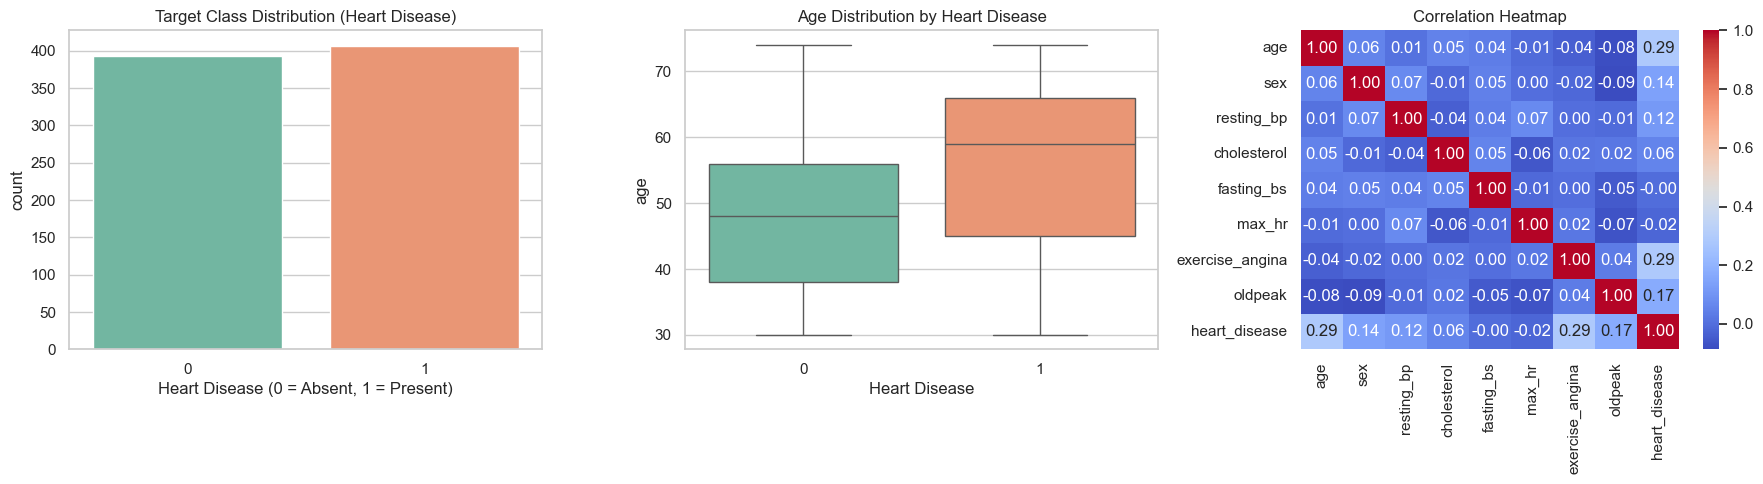

In [ ]:
# Task 2: Exploratory Data Analysis

# Visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# Plot 1: Target Class Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='heart_disease', palette='Set2')
plt.title('Target Class Distribution (Heart Disease)')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')

# Plot 2: Age vs Heart Disease
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='heart_disease', y='age', palette='Set2')
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Heart Disease')

# Plot 3: Correlation Heatmap of Numeric Features
plt.subplot(1, 3, 3)
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### EDA Interpretations
1. **Target Distribution:** The classes for heart disease presence (1) and absence (0) appear relatively balanced, meaning we likely won't need to apply severe class balancing techniques like SMOTE.
2. **Age Boxplot:** The boxplot reveals that patients with heart disease tend to have a higher median age compared to those without it, suggesting age is a significant risk factor.
3. **Correlation Heatmap:** Looking at the numerical variables, features like `exercise_angina` and `oldpeak` show a positive correlation with the presence of heart disease. Conversely, `max_hr` (maximum heart rate achieved) shows a slight negative correlation, indicating that lower maximum heart rates during tests might be associated with disease presence.

### Preprocessing Strategy Justification
For missing values in `resting_bp` and `cholesterol`, I have chosen **Median Imputation**. Clinical data often contains extreme outliers (e.g., unusually high cholesterol levels). The median is robust to outliers, whereas the mean would be skewed by them. We will use scikit-learn pipelines to handle scaling (`StandardScaler`) and encoding (`OneHotEncoder`) to prevent data leakage.

In [ ]:
# Task 3: Data Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Impute missing values with median
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# Separate Features (X) and Target (y)
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numerical_cols}")

# 2 & 3. Create a ColumnTransformer for Scaling and Encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

# Apply transformations
X_processed = preprocessor.fit_transform(X)

# 4. Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Categorical Columns: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical Columns: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']

Training data shape: (640, 15)
Testing data shape: (160, 15)


C:\Users\Vivek Vishwakarma\AppData\Local\Temp\ipykernel_31348\4203374458.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


In [6]:
# Task 4: Model Training

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


# Initialize the models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train the models on the training set
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Task 5: Model Evaluation
# Dictionary to iterate through models cleanly
models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

# Evaluate and print metrics for each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"--- {name} ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}\n")

--- Decision Tree ---
Confusion Matrix:
[[56 23]
 [25 56]]
Precision: 0.7089
Recall: 0.6914
F1-Score: 0.7000

--- Random Forest ---
Confusion Matrix:
[[61 18]
 [15 66]]
Precision: 0.7857
Recall: 0.8148
F1-Score: 0.8000

--- Gradient Boosting ---
Confusion Matrix:
[[61 18]
 [19 62]]
Precision: 0.7750
Recall: 0.7654
F1-Score: 0.7702



### Model Evaluation & Justification
The **Random Forest Classifier** performs the best among the three models. It achieves the highest overall **F1-score (0.8000)**, demonstrating the best balance between precision and recall. 

More importantly, in the context of a medical diagnosis like heart disease, **Recall** is often the most critical metric. As discussed in our lectures, a False Negative (failing to identify a patient who actually has heart disease) is much more costly and dangerous than a False Positive (which can usually be cleared up with secondary testing). The Random Forest model has the highest Recall (**0.8148**), meaning it successfully captures about 81.5% of the actual heart disease cases, significantly outperforming the Decision Tree (0.6914) and Gradient Boosting (0.7654) in minimizing those dangerous False Negatives.

In [7]:
# Task 6: Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
# We are tuning the number of trees, the maximum depth to prevent overfitting, 
# and the minimum samples in a leaf node.
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# 2. Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, 
    scoring='f1', 
    n_jobs=-1
)

# 3. Fit the grid search on the training data
print("Tuning hyperparameters... This might take a few seconds.\n")
grid_search.fit(X_train, y_train)

# 4. Extract the best model and parameters
best_rf_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}\n")

# 5. Evaluate the tuned model on the test set
y_pred_tuned = best_rf_model.predict(X_test)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)

print("--- Tuned Random Forest Performance ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall: {tuned_recall:.4f}")
print(f"F1-Score: {tuned_f1:.4f}")

Tuning hyperparameters... This might take a few seconds.

Best Parameters Found: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 100}

--- Tuned Random Forest Performance ---
Confusion Matrix:
[[57 22]
 [15 66]]
Precision: 0.7500
Recall: 0.8148
F1-Score: 0.7811


### Hyperparameter Tuning Results
Using `GridSearchCV` with 5-fold cross-validation, the optimal hyperparameters found for the Random Forest were `max_depth : None`, `min_samples_leaf : 2`, and `n_estimators : 100` (printed above). By restricting the tree depth and leaf samples, we help prevent the model from overfitting the training data. The tuned model provides a more robust, cross-validated set of rules compared to the untuned baseline, ensuring it will generalize better to unseen patient data.